<a href="https://colab.research.google.com/github/MukulVerma-ML/Machine-Learning-Projects/blob/main/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df =pd.read_excel('red_wine.xlsx')

In [ ]:
df.shape
df.head()
df.info()
df['quality'].value_counts().sort_index()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [ ]:
df['good']= df['quality'].apply(lambda x: 1 if x>=7 else 0)

print("good wine:",df['good'].sum())
print("bad wine:",(len(df)-df['good'].sum()))

good wine: 217
bad wine: 1382


In [ ]:
X=df.drop(['quality','good'],axis=1)
Y=df['good']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [ ]:
#Random Forest model

rf=RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced')
rf.fit(X_train,Y_train)

Y_pred=rf.predict(X_test)
print("Accuracy:",accuracy_score(Y_test,Y_pred))
print("Classification Report:",classification_report(Y_test,Y_pred))
print("Confusion Matrix:",confusion_matrix(Y_test,Y_pred))

Accuracy: 0.946875
Classification Report:               precision    recall  f1-score   support

           0       0.95      1.00      0.97       277
           1       0.96      0.63      0.76        43

    accuracy                           0.95       320
   macro avg       0.95      0.81      0.87       320
weighted avg       0.95      0.95      0.94       320

Confusion Matrix: [[276   1]
 [ 16  27]]


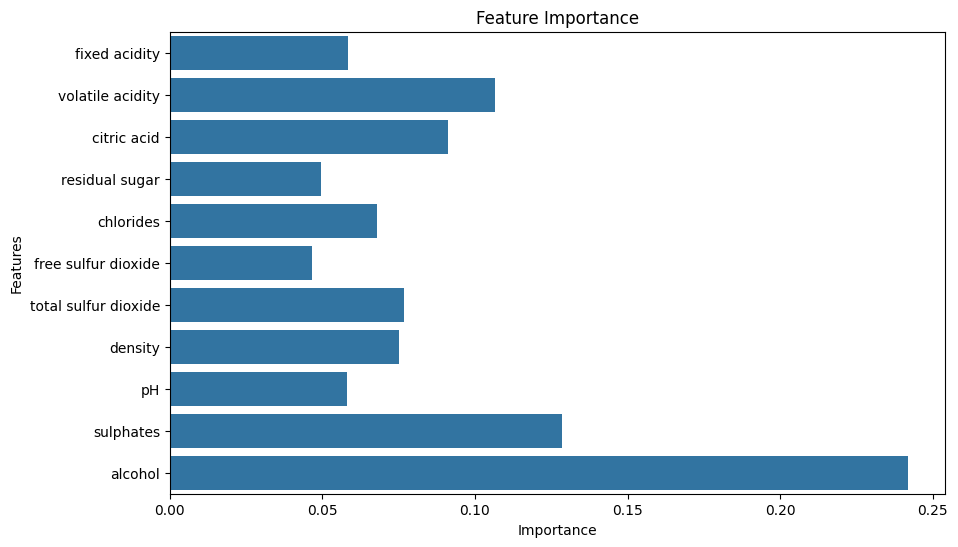

In [ ]:
#graph:1- Feature Importance(konsa chemical important)

plt.figure(figsize=(10,6))
sns.barplot(x=rf.feature_importances_,y=X.columns)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

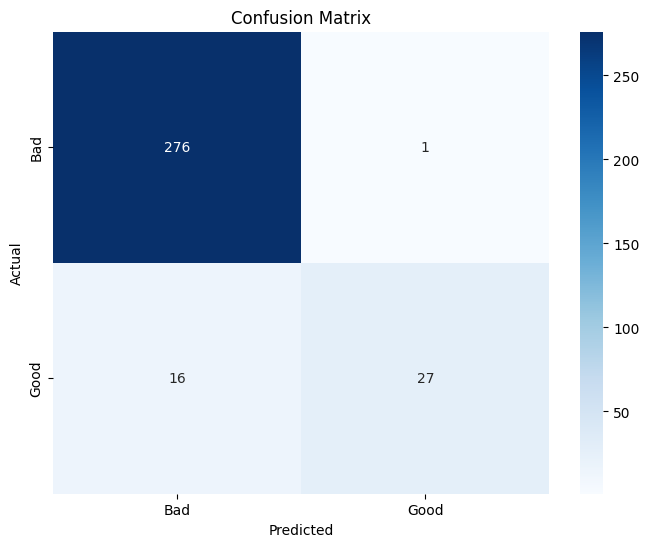

In [ ]:
# graph:2- Confusion Matrix

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(Y_test,Y_pred),annot=True,fmt='d',cmap='Blues',xticklabels=['Bad','Good'],yticklabels=['Bad','Good'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()